In [1]:
!pip install -q PyMuPDF google-genai
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GEMINI_API_KEY")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 59.0 MB/s eta 0:00:00


In [2]:
import base64, json, re, time
from pathlib import Path
from collections import defaultdict
from google import genai
from collections import Counter

# Config
PDF_PATH = "/kaggle/input/datasets/deeppast/old-assyrian-kltepe-tablets-in-pdf/AKT 3 1995.pdf"  # adjust to your dataset path
OUTPUT_DIR = Path("./akt_top_bottom_de/")
OUTPUT_DIR.mkdir(exist_ok=True)

CHUNK_SIZE = 10    # pages per chunk
OVERLAP = 2        # page overlap between chunks
DPI = 576          # high-res for diacritics
MODEL = "models/gemini-3.1-flash-lite-preview"

# Init client
client = genai.Client(api_key=secret_value_0)

In [3]:
PROMPT = """
------------------------GERMAN TO ENGLISH SUPPLEMENT (Larsen/OAA Style)------------------------
This supplement provides German→English vocabulary mappings for ICK 4 (Hecker) texts.
Use alongside the master Dataset_Instructions.txt conventions.

## German→English Vocabulary Mappings

### Commodities & Materials
- Zinn → "tin" (never "lead")
- Silber → "silver"
- Gold → "gold"
- Gewand/Stoff → "textile" (never "garment" or "cloth")
- Kutānum-Stoff → "kutānum-textile"
- schwarzer Stoff → "black textile"
- Esel → "donkey"
- Rind → "ox"
- Bronze → "bronze"

### People & Professions
- Kaufmann/Gläubiger → "merchant"
- Diener/Bursche → "employee" (or "servant" in domestic contexts)
- Sklavin → "slave-girl" (hyphenated)
- Sklave → "slave"
- Anwalt/Kommissär → "attorney"
- Bote/Reisender → "traveller"
- Packer/Karawanenführer → "transporter" (or "harnesser")
- Bruder → "brother" (may mean "colleague" in business)
- Herr → "lord" or "boss" (in business contexts)

### Financial & Legal Terms
- Geldbeutel/Sack (naruqqum) → "joint-stock fund" (abstract) or "sack" (physical)
- Betriebskapital (be'ūlātum) → "working capital"
- Kaufpreis/Erlös (šīmum) → "purchase" or "proceeds"
- Zins (ṣibtum) → "interest"
- Tafel/Urkunde (ṭuppum) → "tablet" or "document"
- Hüllentafel (ṭuppum ḫarmum) → "certified tablet"
- Hand/Anteil (qātum) → "share" or "claim"
- Karawane (ellat) → "caravan"
- Abrechnung (nikkassū) → "accounts"
- Abgabe (šaddu'utum) → "transport tariff"
- Wegerecht/Gebühr (datum) → "road-tax"
- Zehnt (išrātum) → "tithe"
- Eid der Stadt (nīš ālim) → "oath of the City"

### Terms to Keep Untranslated
- kārum (Hafen/Kolonie) → keep as "kārum"
- wubārtum (Station) → keep as "wubārtum"

### Judicial & Procedural Terms (common in ICK 4)
- Urteil des Kārum (dīn kārim) → "verdict of the colony"
- Wort/Sache/Angelegenheit (awātum) → "case" or "affair" (legal contexts)
- Zeugen (šībū) → "witnesses"
- Schafschur (buqūmum) → "plucking time"
- Hand legen (qātam šakānum) → "to lay claim"

### Direction Terms (preserve topography)
- hinaufgehen (elā'um) → "to go up" (travel toward Assur)
- hinabgehen (warādum) → "to go down" (travel toward Kanesh)

### Special Notes
- "City" (capitalized) always refers to Assur
- "city" (lowercase) refers to local Anatolian towns
- ṣubāt ša qātim → "quality textile"
-------------------------------------------------------------------------------

I am uploading a PDF document containing pages of Old Assyrian/Akkadian texts. I need you to perform a structured data extraction.
It is critical to read the pages in order.

**ROLE:**
You are an expert Assyriologist and Data Engineer. You are processing a PDF document of Old Assyrian/Akkadian texts.

**GOAL:**
Perform a structured data extraction of Transliteration and Translation pairs.

**INPUT PROCESSING RULES:**
1.  **Read Order:** You must read the pages in strict numerical order.
2.  **Visual Layout:** Look specifically for **Distinct Columns** of Old Assyrian/Akkadian Transliterations (often containing line counts like 1, 5', rev.) and their corresponding paragraphs of English/Turkish Translation.
3.  **Ignore:** Introductions, footnotes, commentary, and bibliographies that span the full width of the page.

------------------------EXAMPLE PAGE SECTION------------------------

I 437

braun-schwarze Tafel, 8 x 6 x 2,2 cm; Kopie Tafel XIV-XV.

Brief der Aḫaḫa an ihren Bruder Buzāzu, in dem diese auf Zusendung eines ihr testamentarisch zustehenden Betrags von 10 M. Silber besteht. Ferner informiert sie den B., daß der Versuch, bei Bēlānum Zinn zu beschaffen, mißlungen ist.

```text
Vs.      1    a-na Bu-za-zu qí-bi-ma
              um-ma A-ha-ha-ma
              KÙ.BABBAR ša Ku-lu-ma-a
              a-ma-lá ší-ma-tim
         5    a-ma-kam a-ma-ma-an lá ta-da-an-ma
              lá i-ṭá-hi KÙ.BABBAR (Ras.)
              [l]i-ki-ni-ik-ma a-na a-lim{ki}
              [šé]-bi-lam i-na 40 ma-na
              [K]Ù.BABBAR lū qá-tí / lū i-li-bi
        10    Puzur₄-A-šùr ta-ad-mì-iq-tum
              i-ba-ší KÙ.BABBAR 10 ma-na
              ku-un-kà-ma e-né-a pí-té
              a-na Puzur₄-A-šùr
u. K.         ša-am-ri-iṣ a-li-ma
        15    a-wa-tù-šu-<ni> ki-ma KÙ.BABBAR
              10 ma-na ší-bu-tí-ma

Rs.           ga-ma-lim / tí-da?-am
              [x x]-ba-am / (Ras.)
              [.........] KÙ.BABBAR
        20    [..........]-it-ma
              [..........] x ru-ba-am
              [..........]-um
              [... Puzur₄-A]-šur iš-pu-ra-am (Ras.)
              [um-ma šu-ut-ma] /
        25    KÙ.BABBAR li-qé-ma lá ú-kà-lá-ku-nu-tí (Ras.)
              šu-up-ra-am-ma
              úz-ni pí-té-ma lu i-de₈
              a-na Be-lá-nim ša ta-áš-pu-ra-ni
              um-ma a-ta-ma AN.NA
        30    li-dí-na-ki-im e-ri-šu-ma
o. K.         um-ma Be-lá-num-ma AN.NA lá-šu
              a-na gám-ri-im ša É a-bi₄-ku-nu
              [lá] a[g]?-ta-mar? a-ta ma-lá-ak
l. S.         [m]i-š[u š]a ta-ki-l[i ta-áš-t]a-na-me-ú
        35    i-n[a] ša / x [........]-kà-ku-ma
              x x x ma x [......... t]a-zi-iz
```

<div style="page-break-after: always;"></div>

<sup>1-2)</sup>An Buzāzu, folgendermaßen Aḫaḫa: <sup>3-6)</sup>Das Silber des Kulūmāja gib dort entsprechend den testamentarischen Bestimmungen niemandem, und niemand soll sich (ihm) nähern. <sup>6-8)</sup>Das Silber soll gesiegelt werden; [sch]icke es dann her in die Stadt. <sup>8-12)</sup>Von den 40 M. Silber, sei es mein Anteil oder sei es, daß ein zinsloses Darlehen zu Lasten von Puzur-Aššur vorhanden ist, siegle 10 M. und öffne meine Augen. <sup>13-17)</sup>Wegen Puzur-Aššur setze (denen) zu, wo immer Rechtsfälle von ihm (anliegen). Wie man wegen 10 M. Silber (sogar) den Zeugen gefällig sein kann, weißt du. <sup>18-23)</sup>(Größtenteils abgebr.) <sup>23-27)</sup>[Puzur-A]ššur schrieb mir [folgendermaßen:] „Nimm das Silber; er soll es euch nicht vorenthalten! Schreibe mir und informiere mich, damit ich Bescheid weiß!" <sup>28-30)</sup>Was das betrifft, daß du mir wegen Bēlānum folgendermaßen schriebst: „Er soll dir Zinn geben", so verlangte ich es von ihm. <sup>30-33)</sup>Bēlānum (sprach aber) folgendermaßen: „Es ist kein Zinn vorhanden. Habe ich es denn nicht für die Ausgaben des Hauses eures Vaters ausgegeben?" <sup>33-36)</sup>Jetzt liegt es an dir. [W]a[ru]m hö[rst du im]mer wieder auf Verleumdun[gen]? (Rest weitgehend abgebr.)

Anmerkung:
Z. 16) uš-pá-ru-um dürfte eine aA Nebenform zu dem dort bisher nicht belegten išparum „Weber" sein. Das a der vorletzten Silbe muß wegen der fehlenden Vokal-Harmonie lang oder geschlossen sein.

Anmerkungen:
Z. 1ff.) Die Affäre um die Auszahlung von 10 M. Silber (Z. 11) an die Aḫaḫa ist von Buzāzu sehr hinhaltend betrieben worden und hat auch in die Korrespondenz zwischen Buzāzu und Puzur-Aššur Eingang gefunden. Vgl. M. T. Larsen, CTMMA I zu Text 71. Wieweit über Buzāzu und Bēlānum (vgl. Z. 28 und 31) als Sachwalter (rābiṣum) des Su'e"a (eines der 3 Brüder des Buzāzu) auch Querverbindungen zu dem „Rechtsstreit

------------------------------END OF PAGE---------------------------

**EXTRACTION LOGIC:**
For every detected "Column" block of Old Assyrian/Akkadian Transliterations:

1.  **Identify the ID:** Look immediately above the column for a text identifier (e.g., "1. Kt 86/k 39").
    * *Context Rule:* If a page starts with a continuation of text from the previous page and has no header, use the ID from the previous text.
2.  **Sentence Alignment (Critical):**
    * Group the Transliteration lines to match the logical Translation sentences.
    * **Grammatical Check:** Use verb endings (e.g., *-u* for plural/subjunctive) and case markers to ensure the Transliteration segment matches the Translation's subject and number.
    * **Seal Logic:** Treat lines beginning with KIŠIB (Seal) as discrete list items unless the Turkish translation explicitly groups them into a single sentence[cite: 13].
    * *Note:* One English/Turkish sentence often corresponds to *multiple lines* of Transliteration[cite: 22].
3.  **Page Spanning:**
    * If a sentence starts on one page and ends on the next, **stitch them together** into a single string. Do not output cut-off fragments.
4.  **Pairing Validation:**
    * If a Transliteration block exists but has no translation (or vice versa), **DO NOT output it**. Discard orphaned text.
5.  **Language Processing:**
    * **Detect:** Identify the language of the extracted `translation` text and output its ISO 639-1 code in a `"language"` field (e.g., "en", "tr", "de").
    * **English Fallback:**
        * If `language` is **"en"**: Do not include an `english_translation` field.
        * If `language` is **NOT "en"**: Generate a field `"english_translation"`. Translate the text into **scholarly English**. Do not simply translate the German/Turkish. You must Cross-Reference the Akkadian Transliteration. Meaning: Comes from the German/Turkish. Entities: Personal names, Divine names, and Goods (Silver/Tin) must be normalized from the Akkadian column according to the Dataset_Instructions.txt conventions and the German supplement above.
        * *Style Note:* CRITICAL : When generating the English translation, derive the meaning from the provided translation (e.g., German/Turkish) but derive the proper nouns and technical terms directly from the Akkadian Transliteration.
6.  **Ensure Complete Extraction:** You MUST include ALL transliteration lines from the identified text blocks. Do not leave any transliteration lines out.

**CLEANING RULES:**
1.  **Flattening:** Treat text as a continuous stream. Remove newlines (`\n`) within the text strings.
2.  **Exact OCR:** Keep typos, brackets `[...]`, and special chars (š, ṣ, ṭ, ₄, ₆) exactly as seen.
3.  **Line Numbering:** Use line indicators (1, 5, K., A.y.) for alignment only; they must be removed from the final JSON `transliteration` string.

**QUALITY SCORING:**
Assign a `quality` score:
* **"high":** Text is sharp, English is coherent. (Do NOT lower score for `[...]` or damage brackets—this is expected).
* **"medium":** Image is slightly blurry or text is fragmented.
* **"low":** Text is illegible or translation is nonsensical.

**OUTPUT FORMAT:**
Return the result strictly inside the delimiters below. If no valid pairs are found, return `[]`.

------------------------PARSED SENTENCES------------------------
[
    {
        "id": "I 437",
        "transliteration": "a-na Bu-za-zu qí-bi-ma um-ma A-ha-ha-ma",
        "translation": "An Buzāzu, folgendermaßen Aḫaḫa:",
        "language": "de",
        "english_translation": "To Buzāzu: Thus Aḫaḫa:",
        "quality": "high"
    },
    {
        "id": "I 437",
        "transliteration": "KÙ.BABBAR ša Ku-lu-ma-a a-ma-lá ší-ma-tim a-ma-kam a-ma-ma-an lá ta-da-an-ma lá i-ṭá-hi",
        "translation": "Das Silber des Kulūmāja gib dort entsprechend den testamentarischen Bestimmungen niemandem, und niemand soll sich (ihm) nähern.",
        "language": "de",
        "english_translation": "Give the silver of Kulūmāja to no one there in accordance with the testamentary provisions, and no one should approach (it).",
        "quality": "high"
    },
    {
        "id": "I 437",
        "transliteration": "KÙ.BABBAR [l]i-ki-ni-ik-ma a-na a-lim{ki} [šé]-bi-lam",
        "translation": "Das Silber soll gesiegelt werden; [sch]icke es dann her in die Stadt.",
        "language": "de",
        "english_translation": "The silver should be sealed; send it here to the City.",
        "quality": "high"
    },
    {
        "id": "I 437",
        "transliteration": "i-na 40 ma-na [K]Ù.BABBAR lū qá-tí / lū i-li-bi Puzur₄-A-šùr ta-ad-mì-iq-tum i-ba-ší KÙ.BABBAR 10 ma-na ku-un-kà-ma e-né-a pí-té",
        "translation": "Von den 40 M. Silber, sei es mein Anteil oder sei es, daß ein zinsloses Darlehen zu Lasten von Puzur-Aššur vorhanden ist, siegle 10 M. und öffne meine Augen.",
        "language": "de",
        "english_translation": "From the 40 minas of silver—whether it is my share or whether it is that an interest-free loan is owed by Puzur-Aššur—seal 10 minas of silver and open my eyes.",
        "quality": "high"
    },
    {
        "id": "I 437",
        "transliteration": "a-na Puzur₄-A-šùr ša-am-ri-iṣ a-li-ma a-wa-tù-šu-<ni> ki-ma KÙ.BABBAR 10 ma-na ší-bu-tí-ma ga-ma-lim / tí-da?-am",
        "translation": "Wegen Puzur-Aššur setze (denen) zu, wo immer Rechtsfälle von ihm (anliegen). Wie man wegen 10 M. Silber (sogar) den Zeugen gefällig sein kann, weißt du.",
        "language": "de",
        "english_translation": "Press Puzur-Aššur hard wherever his cases are. You know how one can be accommodating to witnesses for the sake of 10 minas of silver.",
        "quality": "high"
    },
    ...
]
------------------------End Of sentences------------------------
"""

In [4]:
import base64, json, re, time, fitz
from pathlib import Path
from collections import defaultdict, Counter
from google import genai
from google.genai import types
from IPython.display import display, HTML

def pdf_to_images(pdf_path, start, end, dpi=DPI):
    doc = fitz.open(pdf_path)
    imgs = []
    for p in range(start, min(end, len(doc))):
        pix = doc[p].get_pixmap(matrix=fitz.Matrix(dpi/72, dpi/72))
        imgs.append(base64.b64encode(pix.tobytes("png")).decode())
    doc.close()
    return imgs

def make_chunks(n_pages):
    chunks, start = [], 0
    while start < n_pages:
        chunks.append((start, min(start + CHUNK_SIZE, n_pages)))
        start += CHUNK_SIZE - OVERLAP
        if start >= n_pages: break
    return chunks

def parse_response(text):
    for s_m, e_m in [
        ("---PARSED CHUNKS---", "---End Of chunks---"),
        ("---PARSED SENTENCES---", "---End Of sentences---"),
    ]:
        s_m = s_m.replace("---", "------------------------")
        e_m = e_m.replace("---", "------------------------")
        s, e = text.find(s_m), text.find(e_m)
        if s != -1 and e != -1:
            json_str = text[s+len(s_m):e].strip()
            break
    else:
        m = re.search(r'\[[\s\S]*\]', text)
        json_str = m.group() if m else "[]"
    json_str = re.sub(r'^```(?:json)?\s*', '', json_str)
    json_str = re.sub(r'\s*```\s*$', '', json_str)
    try:
        parsed = json.loads(json_str)
        return parsed if isinstance(parsed, list) else [parsed]
    except json.JSONDecodeError:
        return [json.loads(m) for m in re.findall(r'\{[^{}]*\}', json_str)
                if 'transliteration' in m]

In [5]:
from google.genai import types

# Config
PDF_PATH = "/kaggle/input/datasets/deeppast/old-assyrian-kltepe-tablets-in-pdf/AKT 3 1995.pdf"
OUTPUT_DIR = Path("./akt_top_bottom_de/")
OUTPUT_DIR.mkdir(exist_ok=True)
CHUNK_SIZE, OVERLAP, DPI = 10, 2, 576
MODEL = "models/gemini-3.1-flash-lite-preview"
client = genai.Client(api_key=secret_value_0)

doc = fitz.open(PDF_PATH)
chunks = make_chunks(len(doc)); doc.close()
print(f"PDF: {len(fitz.open(PDF_PATH))} pages -> {len(chunks)} chunks")

ckpt = OUTPUT_DIR / "checkpoint.jsonl"
done = set()
if ckpt.exists():
    done = {json.loads(l).get('chunk','') for l in open(ckpt) if l.strip()}

t0 = time.time()
for i, (start, end) in enumerate(chunks):
    name = f"p{start}-{end}"
    if name in done:
        print(f"  [{i+1}/{len(chunks)}] {name} — cached"); continue

    t1 = time.time()
    print(f"  [{i+1}/{len(chunks)}] Pages {start}-{end}...", end=" ", flush=True)
    imgs = pdf_to_images(PDF_PATH, start, end)
    contents = ["Extract transliteration/translation pairs from these PDF pages:"]
    contents += [types.Part.from_bytes(data=base64.b64decode(b), mime_type="image/png") for b in imgs]

    try:
        resp = client.models.generate_content(model=MODEL, contents=contents,
            config=types.GenerateContentConfig(system_instruction=PROMPT, temperature=0.3, max_output_tokens=65536))
        pairs = parse_response(resp.text)
        for p in pairs: p['chunk'] = name
        print(f"{len(pairs)} pairs ({time.time()-t1:.1f}s)")
        with open(ckpt, 'a') as f:
            f.write(json.dumps({"chunk": name, "pairs": pairs}, ensure_ascii=False) + '\n')
    except Exception as e:
        print(f"ERROR: {e}")
    time.sleep(3)
    # if len(pairs)>0: break

print(f"Done! Total: {time.time()-t0:.1f}s")

PDF: 217 pages -> 28 chunks
  [1/28] Pages 0-10... 0 pairs (11.0s)
  [2/28] Pages 8-18... 8 pairs (30.6s)
  [3/28] Pages 16-26... 12 pairs (17.9s)
  [4/28] Pages 24-34... 7 pairs (19.1s)
  [5/28] Pages 32-42... 8 pairs (16.9s)
  [6/28] Pages 40-50... 3 pairs (16.9s)
  [7/28] Pages 48-58... 4 pairs (17.5s)
  [8/28] Pages 56-66... 5 pairs (20.0s)
  [9/28] Pages 64-74... 5 pairs (18.9s)
  [10/28] Pages 72-82... 4 pairs (19.1s)
  [11/28] Pages 80-90... 7 pairs (19.3s)
  [12/28] Pages 88-98... 5 pairs (21.3s)
  [13/28] Pages 96-106... 4 pairs (22.8s)
  [14/28] Pages 104-114... 7 pairs (19.3s)
  [15/28] Pages 112-122... 5 pairs (17.8s)
  [16/28] Pages 120-130... 6 pairs (17.2s)
  [17/28] Pages 128-138... 5 pairs (17.4s)
  [18/28] Pages 136-146... 9 pairs (20.0s)
  [19/28] Pages 144-154... 7 pairs (17.2s)
  [20/28] Pages 152-162... 6 pairs (21.4s)
  [21/28] Pages 160-170... 5 pairs (17.6s)
  [22/28] Pages 168-178... 9 pairs (19.2s)
  [23/28] Pages 176-186... 8 pairs (21.6s)
  [24/28] Pages 18

In [6]:
raw = []
for l in open(ckpt):
    if not l.strip(): continue
    entry = json.loads(l)
    for p in entry.get('pairs', []):
        p.setdefault('chunk', entry.get('chunk','')); raw.append(p)

# Intra-chunk dedup
seen, deduped = set(), []
for p in raw:
    k = (p.get('chunk'), p.get('id',''), p.get('transliteration','')[:50])
    if k not in seen: seen.add(k); deduped.append(p)

# Chunk-pick: keep best chunk per tablet
Q = {"high": 0, "medium": 1, "low": 2}
by_tablet = defaultdict(lambda: defaultdict(list))
for p in deduped: by_tablet[p.get('id','')][p.get('chunk','')].append(p)

final = []
for tid in sorted(by_tablet):
    cd = by_tablet[tid]
    if len(cd) == 1: final.extend(list(cd.values())[0]); continue
    def sc(ps):
        n=len(ps); mis=sum(1 for p in ps if p.get('translation','')=='MISSING')
        return (n, n-mis, sum(len(p.get('transliteration','')) for p in ps))
    final.extend(cd[max(cd, key=lambda c: sc(cd[c]))])

# Save & report
with open(OUTPUT_DIR/"akt3_pairs.jsonl",'w') as f:
    for p in final: f.write(json.dumps(p, ensure_ascii=False)+'\n')
print(f"Raw: {len(raw)} → Deduped: {len(deduped)} → Final: {len(final)}")
print(f"Quality: {dict(Counter(p.get('quality','?') for p in final))}")

Raw: 157 → Deduped: 156 → Final: 145
Quality: {'high': 145}


In [7]:
for p in final[:3]:
    print(json.dumps(p, indent=2, ensure_ascii=False))

{
  "id": "Nr. 101",
  "transliteration": "um-ma Kur-ub-Ištar-ma a-na Puzur₄-A-šur dUTU-ba-ni ù Pí-lá-aḫ-Ištar qí-bi-ma a-na dUTU-ba-ni qí-bi-ma",
  "translation": "Folgendermaßen Kurub-Ištar, an Puzur-Aššur, Šamaš-bāni und Pilaḫ-Ištar; an Šamaš-bāni:",
  "language": "de",
  "english_translation": "Thus Kurub-Ištar, to Puzur-Aššur, Šamaš-bāni, and Pilaḫ-Ištar; to Šamaš-bāni:",
  "quality": "high",
  "chunk": "p176-186"
}
{
  "id": "Nr. 101",
  "transliteration": "*ta-áš-pu-ra-am um-ma a-ta-ma 4 GÚ 40 ma-na AN.NA ku-nu-ki *ša ša ki-ma ku-a-tí na-áš-a-ku-um",
  "translation": "Du schriebst mir folgendermaßen: „4 Talent 40 Mine Zinn unter den Siegeln deines Vertreters trägt er zu dir.“",
  "language": "de",
  "english_translation": "You wrote to me as follows: \"He is bringing to you 4 talents 40 minas of tin under the seals of your representative.\"",
  "quality": "high",
  "chunk": "p176-186"
}
{
  "id": "Nr. 101",
  "transliteration": "2 GÚ AN.NA a-na Pí-lá-aḫ-Ištar dí-in / 2 GÚ 40 ma-

ID,Transliteration,English,Quality
kt v/k 2/b,2 ma-na KÙ.BABBAR tí-ri i-ṣé-er A-šùr-ták-lá-ku DUMU I-ku-pí-a DUMU A-šùr-ták-lá-ku ša É Ú-ku-ub-tù-ru-uš E-dí-in-A-šùr DUMU A-šùr-ma-lik i-šu 1 ma-na-um 12 GÍN ṣí-ib-tám ú-ṣa-áb,"2 minas of tiri-silver are owed by Aššur-taklāku, son of Ikuppīja, son of Aššur-taklāku, from the house of Ukub-turūš, to Edin-Aššur. For each mina, he shall pay 12 shekels of interest.",high
kt v/k 2/b,ITU.KAM a-lá-na-t[im] li-mu-um Bé-lí-a DUMU I-na-Sú-en₆,"Month of allānātum, eponymy of Bēlija, son of Inna-Suen.",high
kt v/k 2/b,IGI I-ku-pí-a DUMU Ištar-ba-ni IGI A-šùr-dan DUMU Na-me-a IGI A-ba-a-a DUMU Du-qá-qí-im,"Witnesses: Ikuppīja, son of Ištar-bāni, Aššur-dān, son of Namea, Abā'a, son of Duqāqum.",high
kt v/k 8,KIŠIB A-šùr-ták-lá-ku DUMU Šál-ma-A-šùr KIŠIB Ku-ku-a-nim DUMU Ša-lim-dIM ší-bu-kà KIŠIB A-šùr-ták-lá-ku DUMU A-šùr-mu-da-mì-iq,"Seal of Aššur-taklāku, son of Šalma-Aššur, seal of Kukuānum, son of Šalim-Adad, your witnesses. Seal of Aššur-taklāku, son of Aššur-mudammiq.",high
kt v/k 8,1 1/2 ma-na KÙ.BABBAR tí-ri i-ṣé-er A-šùr-ták-lá-ku DUMU A-šùr-mu-da-mì-iq E-dí-in-A-šùr DUMU A-ḫi-a-a i-šu 1 ma-na-um 12 GÍN ṣí-ib-tám i-na ša-té-en₆ ú-ṣa-áb,"1 1/2 minas of tiri-silver are owed by Aššur-taklāku, son of Aššur-mudammiq, to Edin-Aššur, son of Aḫija. For each mina, he shall pay 12 shekels of interest in two years.",high

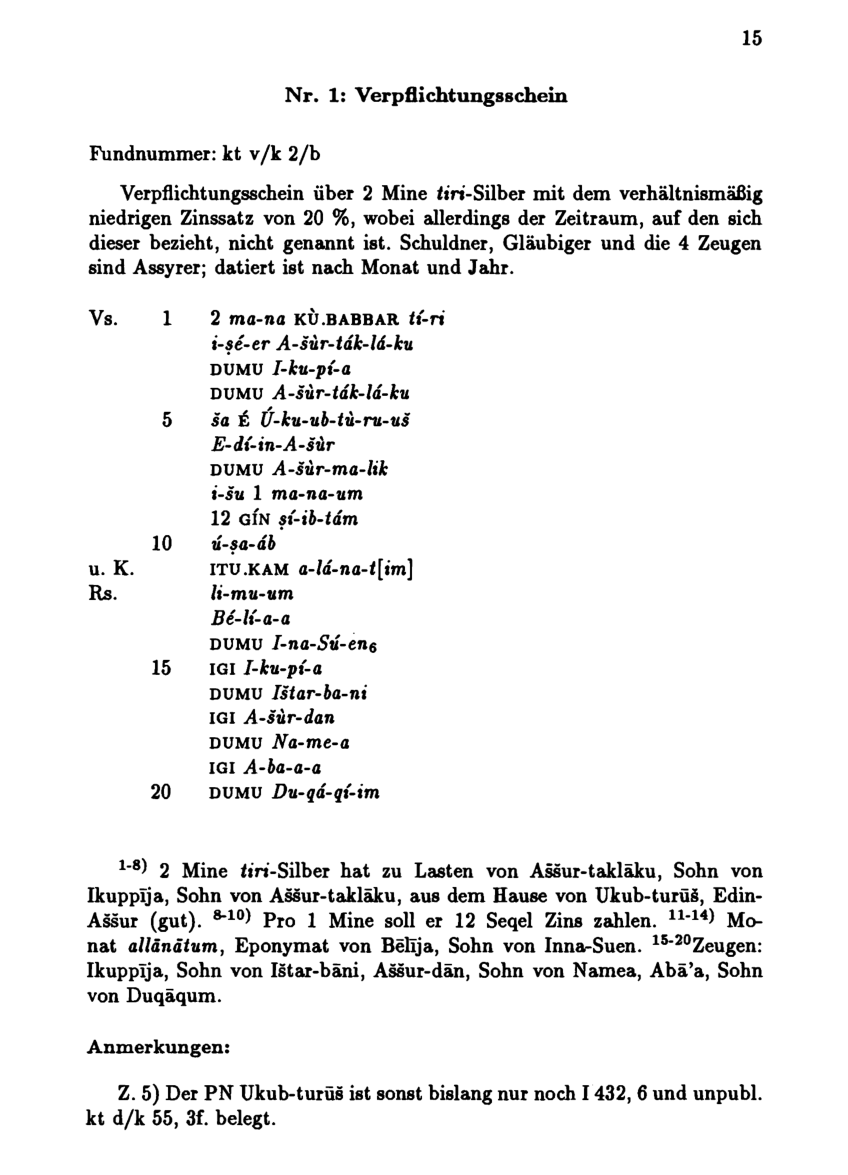

In [8]:
def show_page(page_num, pairs, dpi=150):
    doc = fitz.open(PDF_PATH)
    pix = doc[page_num].get_pixmap(matrix=fitz.Matrix(dpi/72, dpi/72))
    b64 = base64.b64encode(pix.tobytes("png")).decode(); doc.close()
    html = f'<h3>Page {page_num}</h3><img src="data:image/png;base64,{b64}" style="max-width:100%;border:1px solid #ccc;">'
    if pairs:
        html += '<table style="margin-top:10px;border-collapse:collapse;width:100%;"><tr style="background:#f0f0f0;">'
        html += '<th style="border:1px solid #ccc;padding:6px;">ID</th><th style="border:1px solid #ccc;padding:6px;">Transliteration</th>'
        html += '<th style="border:1px solid #ccc;padding:6px;">English</th><th style="border:1px solid #ccc;padding:6px;">Quality</th></tr>'
        for p in pairs:
            html += f'<tr><td style="border:1px solid #ccc;padding:6px;">{p.get("id","")}</td>'
            html += f'<td style="border:1px solid #ccc;padding:6px;font-family:monospace;font-size:12px;">{p.get("transliteration","")}</td>'
            html += f'<td style="border:1px solid #ccc;padding:6px;">{p.get("english_translation",p.get("translation",""))}</td>'
            html += f'<td style="border:1px solid #ccc;padding:6px;">{p.get("quality","")}</td></tr>'
        html += '</table>'
    display(HTML(html))

PAGE = 14
page_pairs = [p for p in final for c in [p.get('chunk','')]
              if (m:=re.match(r'p(\d+)-(\d+)',c)) and int(m[1])<=PAGE<int(m[2])]
show_page(PAGE, page_pairs)